# Analyzing Research Publication Trends with Pandas

In this notebook we'll load a synthetic dataset of ~50,000 journal articles to explore
research output, citation patterns, and collaboration across different academic fields.

**Topics covered:**
1. Data Loading
2. Inspection & summary statistics
3. Filtering & selection
4. Handling missing data
5. Data cleaning & standardization
6. GroupBy & aggregation
7. Merging datasets
8. Pivot tables & crosstabs
9. Time-series resampling
10. Visualization


## 1. Setup & Data Loading

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [30]:
articles = pd.read_csv("pandas_dataset.csv")

In [31]:
articles.head(10)

,Unnamed: 0,article_id,title,field,pub_date,citations,author_count,open_access,funding_source
0,0,1,Article_1,Physics,2024-05-20,21,9,False,Government
1,1,2,Article_2,Chem,2022-11-25,6,5,True,Industry
2,2,3,Article_3,Chemistry,2016-06-19,11,3,True,University
3,3,4,Article_4,Psychology,2021-03-15,36,4,False,University
4,4,5,Article_5,Biology,2018-10-09,11,11,True,Foundation
5,5,6,Article_6,Biology,2018-01-28,18,9,False,NaN
6,6,7,Article_7,Computer Science,2016-02-25,101,6,False,Industry
7,7,8,Article_8,CS,2024-03-31,26,4,True,Foundation
8,8,9,Article_9,Psychology,2024-02-04,4,5,False,Foundation
9,9,10,Article_10,Chemistry,2021-10-12,6,5,False,University


## 2. Data Inspection & Summary Statistics

Let's examine dataset shape, types, and distributions.


In [32]:
articles.shape

(50000, 9)

In [33]:
articles.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0      50000 non-null  int64
 1   article_id      50000 non-null  int64
 2   title           50000 non-null  str  
 3   field           50000 non-null  str  
 4   pub_date        50000 non-null  str  
 5   citations       50000 non-null  int64
 6   author_count    50000 non-null  int64
 7   open_access     50000 non-null  bool 
 8   funding_source  37497 non-null  str  
dtypes: bool(1), int64(4), str(4)
memory usage: 3.1 MB


In [34]:
articles.describe()


,Unnamed: 0,article_id,citations,author_count
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,25000.500000,32.006240,5.008220
std,14433.901067,14433.901067,77.604387,2.001468
min,0.000000,1.000000,0.000000,1.000000
25%,12499.750000,12500.750000,4.000000,4.000000
50%,24999.500000,25000.500000,12.000000,5.000000
75%,37499.250000,37500.250000,31.000000,6.000000
max,49999.000000,50000.000000,4371.000000,16.000000


In [35]:
articles.describe(include="object")


,title,field,pub_date,funding_source
count,50000,50000,50000,37497
unique,50000,12,3469,4
top,Article_1,Physics,2023-09-20,Government
freq,1,7094,30,14876


In [36]:
# Check for missing values
articles.isnull().sum()

Unnamed: 0            0
article_id            0
title                 0
field                 0
pub_date              0
citations             0
author_count          0
open_access           0
funding_source    12503
dtype: int64

## 3. Filtering & Selection

Pandas lets you slice data with boolean conditions — this is something you'll do constantly.


In [37]:
# Open-access CS papers published after 2018 with > 50 citations
# First, convert pub_date to datetime for proper comparisons
articles["pub_date"] = pd.to_datetime(articles["pub_date"])

cs_labels = ["Computer Science", "CS", "Comp Sci"]

high_impact_cs = articles[
    (articles["field"].isin(cs_labels)) &
    (articles["pub_date"] >= "2019-01-01") &
    (articles["citations"] > 50) &
    (articles["open_access"] == True)
]

print(f"Found {len(high_impact_cs)} articles matching the criteria")
high_impact_cs[["article_id", "field", "pub_date", "citations", "author_count"]].head(10)


Found 416 articles matching the criteria


,article_id,field,pub_date,citations,author_count
40,41,Computer Science,2022-04-02,85,4
88,89,Comp Sci,2020-10-26,83,8
100,101,Computer Science,2019-03-30,93,5
183,184,Comp Sci,2024-01-27,260,6
294,295,Computer Science,2022-04-02,182,7
300,301,Computer Science,2021-01-08,235,4
334,335,Computer Science,2021-07-06,69,4
335,336,Computer Science,2020-11-14,66,5
383,384,Comp Sci,2024-05-25,151,5
433,434,Computer Science,2019-09-29,107,4


In [38]:
# Use .query() for a more readable alternative
result = articles.query(
    'field in @cs_labels and pub_date >= "2019-01-01" and citations > 50 and open_access == True'
)
print(f"Same result: {len(result)} articles")


Same result: 416 articles


## 4. Handling Missing Data

Data in real datasets may have gaps. 

Here the `funding_source` column has NaN values,
representing articles whose funding information wasn't recorded.


In [39]:
# How many articles are missing funding info?
missing_funding = articles["funding_source"].isnull().sum()
pct = 100 * missing_funding / len(articles)
print(f"Missing funding_source: {missing_funding} ({pct:.1f}%)")


Missing funding_source: 12503 (25.0%)


In [40]:
# Option A: Fill missing values with a label
articles["funding_filled"] = articles["funding_source"].fillna("Unknown")
articles["funding_filled"].value_counts()


funding_filled
Government    14876
Unknown       12503
University    10215
Industry       7384
Foundation     5022
Name: count, dtype: int64

In [41]:
# Option B: Drop rows with missing funding (careful — you lose data)
articles_complete = articles.dropna(subset=["funding_source"])
print(f"Rows before: {len(articles)}, after dropna: {len(articles_complete)}")


Rows before: 50000, after dropna: 37497


## 5. Data Cleaning & Standardization

Notice that the `field` column has inconsistent names: "Computer Science", "CS", and "Comp Sci"
all mean the same thing. Let's fix it.


In [42]:
# See the messy values
print("Before cleaning:")
print(articles["field"].value_counts())


Before cleaning:
field
Physics             7094
Psychology          7091
Computer Science    7021
Biology             7016
Economics           6933
Chemistry           6900
Chem                2470
CS                  1469
Psych               1033
Bio                 1005
Comp Sci            1000
Econ                 968
Name: count, dtype: int64


In [43]:
# Build a mapping from messy names to canonical names
field_map = {
    "CS":       "Computer Science",
    "Comp Sci": "Computer Science",
    "Bio":      "Biology",
    "Econ":     "Economics",
    "Psych":    "Psychology",
    "Chem":     "Chemistry",
}

articles["field_clean"] = articles["field"].replace(field_map)

print("\nAfter cleaning:")
print(articles["field_clean"].value_counts())



After cleaning:
field_clean
Computer Science    9490
Chemistry           9370
Psychology          8124
Biology             8021
Economics           7901
Physics             7094
Name: count, dtype: int64


## 6. GroupBy & Aggregation

GroupBy is arguably the most important Pandas operation for analysis. It splits your data
into groups, applies a function, and combines the results.


In [44]:
# Mean citations by field
articles.groupby("field_clean")["citations"].mean().sort_values(ascending=False)


field_clean
Chemistry           32.627321
Computer Science    32.336354
Physics             32.316747
Biology             31.993143
Psychology          31.673314
Economics           30.950006
Name: citations, dtype: float64

In [45]:
# Multiple aggregations at once
summary = articles.groupby("field_clean").agg(
    num_articles  = ("article_id", "count"),
    mean_citations = ("citations", "mean"),
    median_citations = ("citations", "median"),
    mean_authors  = ("author_count", "mean"),
    pct_open_access = ("open_access", "mean"),
).round(2)

summary["pct_open_access"] = (summary["pct_open_access"] * 100).round(1)
summary.sort_values("mean_citations", ascending=False)


,num_articles,mean_citations,median_citations,mean_authors,pct_open_access
field_clean,,,,,
Chemistry,9370,32.63,12.0,5.00,44.0
Computer Science,9490,32.34,12.0,5.01,45.0
Physics,7094,32.32,12.0,5.02,45.0
Biology,8021,31.99,12.0,4.99,44.0
Psychology,8124,31.67,12.0,5.02,45.0
Economics,7901,30.95,11.0,5.01,46.0


In [46]:
# Yearly publication counts by field
articles["year"] = articles["pub_date"].dt.year
yearly = articles.groupby(["year", "field_clean"]).size().unstack(fill_value=0)
yearly


field_clean,Biology,Chemistry,Computer Science,Economics,Physics,Psychology
year,,,,,,
2015,842,958,1018,867,759,905
2016,811,1019,981,902,754,880
2017,850,971,983,827,777,835
2018,884,974,971,823,727,869
2019,800,992,1004,828,740,824
2020,884,986,987,793,700,868
2021,838,1024,1038,827,740,788
2022,851,965,1002,783,806,897
2023,816,979,1013,855,719,851


## 7. Merging Datasets

Often your data lives in multiple tables. Let's create a journal-level dataset and merge it
with our articles to see whether journal prestige correlates with citation count.


In [47]:
# Create a synthetic journal impact factor table
journals = pd.DataFrame({
    "field_clean": ["Computer Science", "Biology", "Physics",
                    "Economics", "Psychology", "Chemistry"],
    "avg_impact_factor": [5.2, 7.8, 6.1, 3.4, 4.5, 4.9],
    "avg_review_months":  [4.2, 6.1, 5.0, 8.3, 7.5, 5.8],
})
journals


,field_clean,avg_impact_factor,avg_review_months
0,Computer Science,5.2,4.2
1,Biology,7.8,6.1
2,Physics,6.1,5.0
3,Economics,3.4,8.3
4,Psychology,4.5,7.5
5,Chemistry,4.9,5.8


In [48]:
# Merge on the cleaned field column
merged = articles.merge(journals, on="field_clean", how="left")
print(f"Shape after merge: {merged.shape}")
merged[["article_id", "field_clean", "citations", "avg_impact_factor"]].head()


Shape after merge: (50000, 14)


,article_id,field_clean,citations,avg_impact_factor
0,1,Physics,21,6.1
1,2,Chemistry,6,4.9
2,3,Chemistry,11,4.9
3,4,Psychology,36,4.5
4,5,Biology,11,7.8


In [49]:
# Correlation between impact factor and citations
corr = merged[["citations", "avg_impact_factor", "author_count"]].corr()
print("Correlation matrix:")
corr.round(3)


Correlation matrix:


,citations,avg_impact_factor,author_count
citations,1.000,0.003,-0.005
avg_impact_factor,0.003,1.000,-0.003
author_count,-0.005,-0.003,1.000


## 8. Pivot Tables & Crosstabs

Pivot tables are a powerful way to reshape data for comparison. Let's look at how open-access
status relates to citation counts across fields.


In [50]:
pivot = articles.pivot_table(
    values="citations",
    index="field_clean",
    columns="open_access",
    aggfunc="mean"
).round(1)

pivot.columns = ["Closed Access", "Open Access"]
pivot["OA Advantage (%)"] = ((pivot["Open Access"] / pivot["Closed Access"] - 1) * 100).round(1)
pivot.sort_values("OA Advantage (%)", ascending=False)


,Closed Access,Open Access,OA Advantage (%)
field_clean,,,
Economics,29.8,32.3,8.4
Computer Science,32.7,31.9,-2.4
Biology,32.4,31.5,-2.8
Psychology,32.1,31.2,-2.8
Chemistry,33.2,31.9,-3.9
Physics,33.0,31.4,-4.8


In [51]:
# Crosstab: field × funding source (counts)
ct = pd.crosstab(articles["field_clean"], articles["funding_filled"], margins=True)
ct


funding_filled,Foundation,Government,Industry,University,Unknown,All
field_clean,,,,,,
Biology,799,2355,1193,1631,2043,8021
Chemistry,917,2830,1356,1872,2395,9370
Computer Science,990,2834,1413,1911,2342,9490
Economics,787,2359,1149,1655,1951,7901
Physics,709,2076,1067,1494,1748,7094
Psychology,820,2422,1206,1652,2024,8124
All,5022,14876,7384,10215,12503,50000


## 9. Time-Series Resampling

Since we have publication dates, we can look at trends over time using Pandas' powerful
datetime and resampling features.


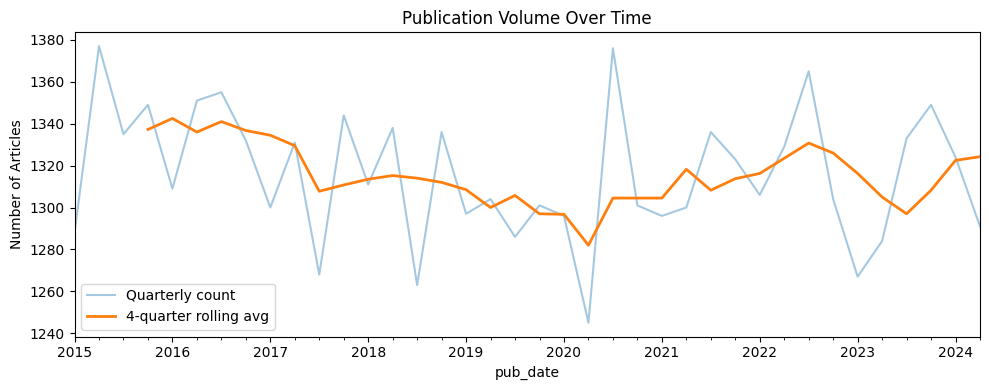

In [52]:
# Set date as index for resampling
ts = articles.set_index("pub_date")

# Quarterly publication counts
quarterly = ts.resample("QE").size()
quarterly.name = "num_articles"

# 4-quarter rolling average to smooth noise
rolling_avg = quarterly.rolling(window=4).mean()

fig, ax = plt.subplots(figsize=(10, 4))
quarterly.plot(ax=ax, alpha=0.4, label="Quarterly count")
rolling_avg.plot(ax=ax, linewidth=2, label="4-quarter rolling avg")
ax.set_title("Publication Volume Over Time")
ax.set_ylabel("Number of Articles")
ax.legend()
plt.tight_layout()
plt.show()


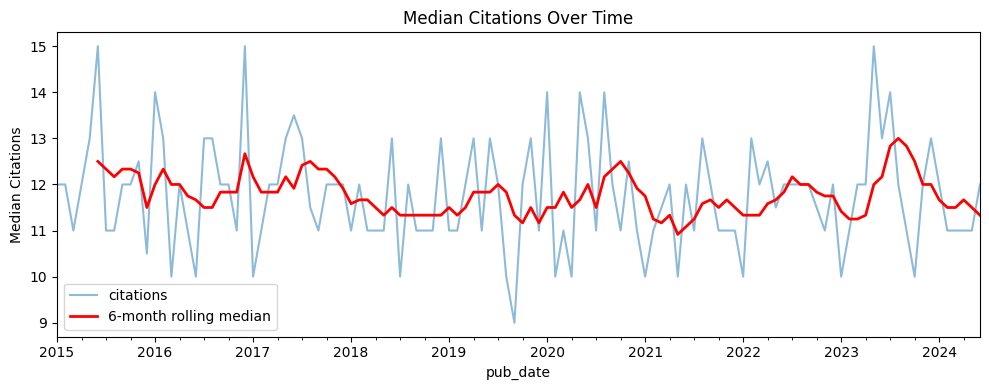

In [53]:
# Monthly median citations — are recent papers cited less (recency bias)?
monthly_cites = ts.resample("ME")["citations"].median()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_cites.plot(ax=ax, alpha=0.5)
monthly_cites.rolling(6).mean().plot(ax=ax, linewidth=2, color="red", label="6-month rolling median")
ax.set_title("Median Citations Over Time")
ax.set_ylabel("Median Citations")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Visualization

Pandas integrates with Matplotlib for quick exploratory plots. For publication-quality
figures you'd typically use Seaborn or Plotly, but Pandas gets you 80% of the way.


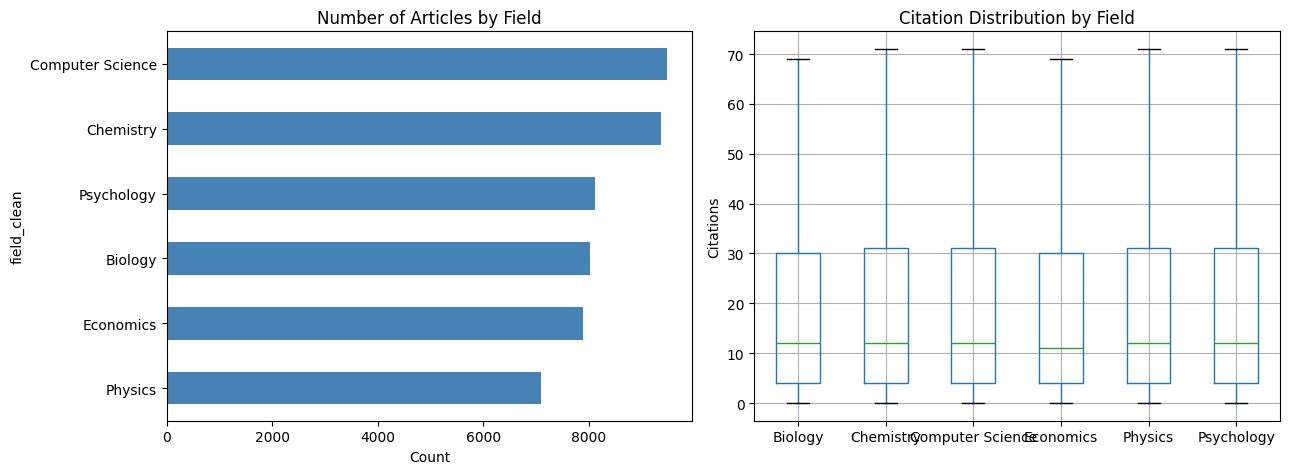

In [54]:
# Bar chart: articles per field
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

articles["field_clean"].value_counts().sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Number of Articles by Field")
axes[0].set_xlabel("Count")

# Box plot: citation distributions by field
articles.boxplot(column="citations", by="field_clean", ax=axes[1], vert=True, showfliers=False)
axes[1].set_title("Citation Distribution by Field")
axes[1].set_xlabel("")
axes[1].set_ylabel("Citations")
plt.suptitle("")  # remove auto-generated title
plt.tight_layout()
plt.show()


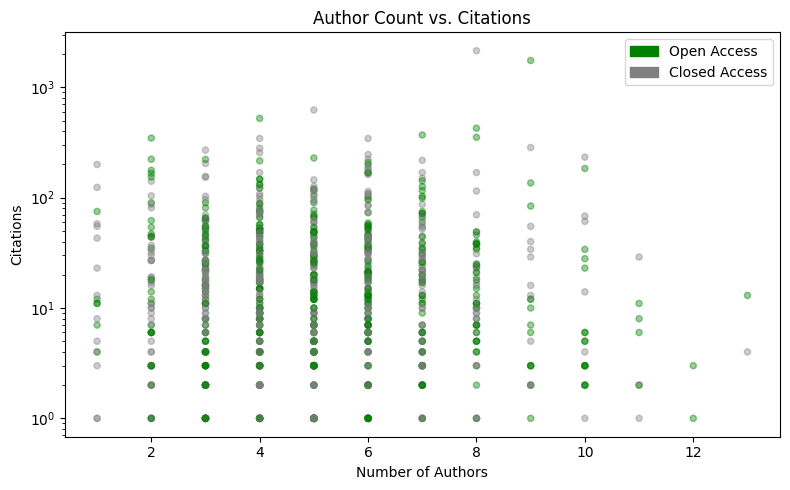

In [55]:
# Scatter: author count vs. citations (sampled for readability)
sample = articles.sample(1000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sample["open_access"].map({True: "green", False: "gray"})
ax.scatter(sample["author_count"], sample["citations"], c=colors, alpha=0.4, s=20)
ax.set_xlabel("Number of Authors")
ax.set_ylabel("Citations")
ax.set_title("Author Count vs. Citations")
ax.set_yscale("log")

# Manual legend
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="green", label="Open Access"),
    mpatches.Patch(color="gray",  label="Closed Access"),
])
plt.tight_layout()
plt.show()


## Summary & Next Steps

In this notebook we looked at:

| Skill | Key Methods |
|---|---|
| Loading & inspection | `pd.DataFrame()`, `.info()`, `.describe()` |
| Filtering | Boolean indexing, `.query()`, `.isin()` |
| Missing data | `.isnull()`, `.fillna()`, `.dropna()` |
| Cleaning | `.replace()`, `.map()` |
| Aggregation | `.groupby()`, `.agg()` |
| Merging | `.merge()` |
| Reshaping | `.pivot_table()`, `pd.crosstab()` |
| Time series | `.resample()`, `.rolling()` |
| Plotting | `.plot()`, `.boxplot()` |

**Next steps:**
- Try loading your own research data and applying these techniques
- Explore **Seaborn** for statistical visualizations
- Explore **Polars**, **Dask** or **DuckDB** if your datasets grow beyond what Pandas can handle